# AUC - ROC Curve

# ROC(Receiver Operating Characteristic Curve)

### It is used to evaluate the performance of a classification model.
### Instead of looking only at accuracy, ROC tells us: 
##### How well the model separates Class 0 and Class 1.

### X-axis = FPR (False Positive Rate)
### Y-axis = TPR (True Positive Rate)

## True Positive Rate (Recall)
### TPR = TP / (TP + FN)

## False Positive Rate
### FPR = FP / (FP + TN)

In [4]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer

In [5]:
df = load_breast_cancer()

X = df.data
y = df.target

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [7]:
lr = LogisticRegression(
    max_iter = 10000
)

In [8]:
lr.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [16]:
# Predict the probability of each class
# for all samples in the test dataset.
#
# predict_proba() returns probabilities
# for both classes:
#
# Column 0 → Probability of class 0
# Column 1 → Probability of class 1
#
# [:,1] selects only the probabilities
# of class 1, which are required for
# ROC Curve and AUC calculation.

y_prob = lr.predict_proba(
    X_test
)[:,1]

In [17]:
from sklearn.metrics import roc_curve

In [18]:
# Calculate the values required
# to plot the ROC Curve.
#
# roc_curve() computes:
#
# fpr       → False Positive Rate values
# tpr       → True Positive Rate values
# threshold → Different probability thresholds
#
# These values are then used
# to draw the ROC Curve graph.

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

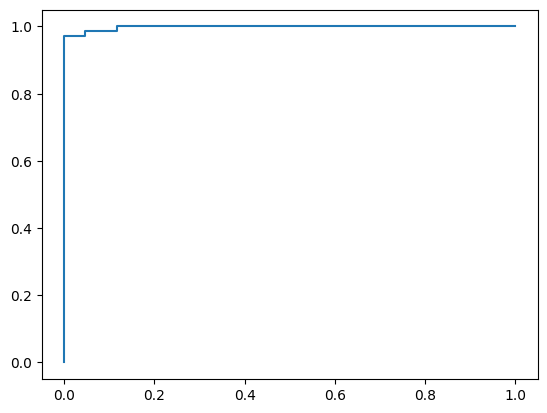

In [20]:
plt.plot(
    fpr,
    tpr
)

plt.show()

In [29]:
# Display the first 5 predicted probabilities
# of the positive class (class = 1).
#
# This is used to check whether the model
# has generated probability values correctly
# before creating the ROC Curve.

print(
    y_prob[:5]
)

[8.78417737e-01 3.04735433e-08 1.59969809e-03 9.98775726e-01
 9.99858607e-01]


In [27]:
from sklearn.metrics import roc_auc_score

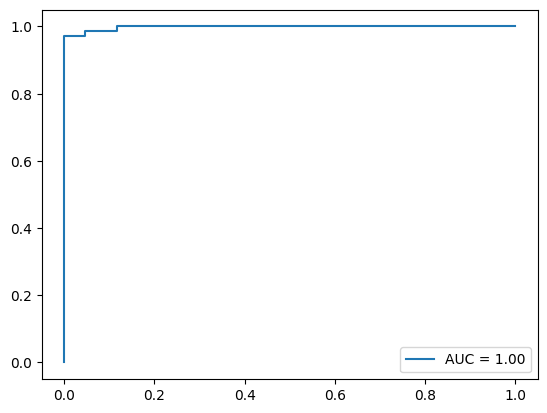

In [28]:
auc = roc_auc_score(y_test, y_prob)

plt.plot(
    fpr,
    tpr,
    label = f'AUC = {auc:.2f}'
)

plt.legend()

# AUC(Area Under Curve)
#### AUC = 1.0    → Perfect model
#### AUC = 0.9    → Excellent model
#### AUC = 0.8    → Good model
#### AUC = 0.7    → Average model
#### AUC = 0.5    → Random guessing